# 🧠 ใบงานสัปดาห์ที่ 06 — โครงข่ายประสาทเทียม (Multi-Layer Perceptron - MLP)

---

**รายวิชา:** 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล | ภาคการศึกษา 1/2569  
**รหัสกลุ่ม:** TEAM-99  
**สมาชิกกลุ่ม:**  
1. น.ส.กมลวรรณ จันทร์ผึ้ง (001)  
2. น.ส.ชลดา อิศรเสนา ณ อยุธยา (009)  
3. น.ส.ณัฐพร เผือกผ่อง (016)  
**หัวข้อโครงงาน:** AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (JobSatisfaction)  
**ชุดข้อมูล:** IBM HR Analytics Employee Attrition & Performance (1,470 แถว × 35 คอลัมน์)  

---

### 📌 วัตถุประสงค์และภาพรวม
การสร้างและฝึกสอน Neural Network ด้วย Keras/TensorFlow โครงสร้าง Dense(8-4-4) ปรับสเกลข้อมูลด้วย MinMaxScaler และวิเคราะห์ Loss/Accuracy Curve


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


In [17]:
import pandas as pd

df = pd.read_csv("clean (4).csv")

In [3]:
print(df.shape)

(1470, 43)


In [4]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TotalSatisfaction', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree']


In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalSatisfaction,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,0.547619,1,Travel_Rarely,0.715820,1,2,1,1,2,Female,...,7,False,False,True,False,True,False,False,False,False
1,0.738095,0,Travel_Frequently,0.126700,8,1,1,2,3,Male,...,9,False,True,False,False,True,False,False,False,False
2,0.452381,1,Travel_Rarely,0.909807,2,2,1,4,4,Male,...,9,False,True,False,False,False,False,False,True,False
3,0.357143,0,Travel_Frequently,0.923407,3,4,1,5,4,Female,...,10,False,True,False,False,True,False,False,False,False
4,0.214286,0,Travel_Rarely,0.350036,2,1,1,7,1,Male,...,7,False,True,False,False,False,False,True,False,False


In [9]:
features = ["JobLevel", "Age", "MonthlyIncome", "YearsAtCompany"]

X_raw = df[features]
y = df["JobSatisfaction"]

print("ค่าหายในฟีเจอร์:", X_raw.isna().sum().sum())
print("จำนวนแต่ละระดับความพึงพอใจ:")
print(y.value_counts().sort_index())
print(
    "สัดส่วนแต่ละระดับ:\n",
    round(y.value_counts(normalize=True).sort_index(), 3)
)

ค่าหายในฟีเจอร์: 0
จำนวนแต่ละระดับความพึงพอใจ:
JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64
สัดส่วนแต่ละระดับ:
 JobSatisfaction
1    0.197
2    0.190
3    0.301
4    0.312
Name: proportion, dtype: float64


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

print("ช่วงค่าหลังสเกล — min:", X.min(), "max:", X.max())


ช่วงค่าหลังสเกล — min: 0.0 max: 1.0


In [11]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1176, 4) (294, 4)


In [12]:
# 1) ฟีเจอร์ยังอยู่ในช่วง 0–1 หลังแบ่งหรือไม่
print("X_train min:", X_train.min(), " max:", X_train.max())
print("X_test  min:", X_test.min(), " max:", X_test.max())

X_train min: 0.0  max: 1.0
X_test  min: 0.0  max: 1.0


In [13]:
# 2) ตรวจสัดส่วนคลาสของ train/test เทียบกับข้อมูลทั้งหมด
print(
    "สัดส่วนคลาส train:\n",
    round(y_train.value_counts(normalize=True).sort_index(), 3)
)
print(
    "สัดส่วนคลาส test:\n",
    round(y_test.value_counts(normalize=True).sort_index(), 3)
)
print(
    "สัดส่วนคลาสทั้งหมด:\n",
    round(y.value_counts(normalize=True).sort_index(), 3)
)


สัดส่วนคลาส train:
 JobSatisfaction
1    0.196
2    0.190
3    0.301
4    0.312
Name: proportion, dtype: float64
สัดส่วนคลาส test:
 JobSatisfaction
1    0.197
2    0.190
3    0.299
4    0.313
Name: proportion, dtype: float64
สัดส่วนคลาสทั้งหมด:
 JobSatisfaction
1    0.197
2    0.190
3    0.301
4    0.312
Name: proportion, dtype: float64


In [16]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

y_train_nn = y_train - 1
y_test_nn = y_test - 1

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(4, activation="softmax"),
])

In [18]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96 (384.00 B)

 Trainable params: 96 (384.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:

history = model.fit(
    X_train,
    y_train_nn,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)


In [23]:


loss_tr, acc_tr = model.evaluate(X_train, y_train_nn, verbose=0)
loss, acc = model.evaluate(X_test, y_test_nn, verbose=0)
print("train accuracy:", round(acc_tr, 3))
print("test  accuracy:", round(acc, 3))


train accuracy: 0.332
test  accuracy: 0.299


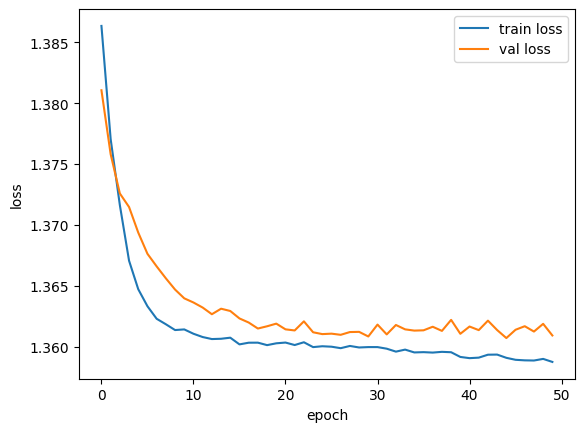

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

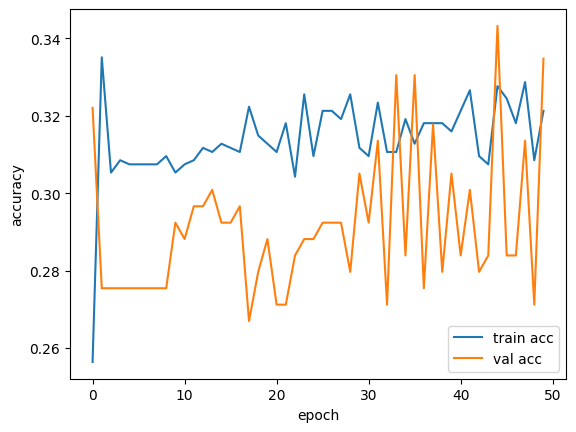

In [26]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [27]:
proba = model.predict(X_test[:5])

for i, p in enumerate(proba):
    predicted_level = int(p.argmax()) + 1
    actual_level = int(y_test.iloc[i])

    print(
        "ความน่าจะเป็นแต่ละระดับ:",
        [round(float(value), 3) for value in p],
        "-> ทำนาย:",
        predicted_level,
        "จริง:",
        actual_level
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
ความน่าจะเป็นแต่ละระดับ: [0.198, 0.21, 0.288, 0.304] -> ทำนาย: 4 จริง: 3
ความน่าจะเป็นแต่ละระดับ: [0.196, 0.191, 0.307, 0.306] -> ทำนาย: 3 จริง: 4
ความน่าจะเป็นแต่ละระดับ: [0.195, 0.181, 0.317, 0.307] -> ทำนาย: 3 จริง: 1
ความน่าจะเป็นแต่ละระดับ: [0.204, 0.189, 0.304, 0.303] -> ทำนาย: 3 จริง: 1
ความน่าจะเป็นแต่ละระดับ: [0.196, 0.186, 0.313, 0.306] -> ทำนาย: 3 จริง: 4


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test).argmax(axis=1) + 1

print(confusion_matrix(y_test, pred, labels=[1, 2, 3, 4]))
print(
    classification_report(
        y_test,
        pred,
        labels=[1, 2, 3, 4],
        target_names=["ระดับ 1", "ระดับ 2", "ระดับ 3", "ระดับ 4"],
        zero_division=0
    )
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[ 0  0 28 30]
 [ 0  0 33 23]
 [ 0  0 46 42]
 [ 0  0 50 42]]
              precision    recall  f1-score   support

     ระดับ 1       0.00      0.00      0.00        58
     ระดับ 2       0.00      0.00      0.00        56
     ระดับ 3       0.29      0.52      0.38        88
     ระดับ 4       0.31      0.46      0.37        92

    accuracy                           0.30       294
   macro avg       0.15      0.24      0.19       294
weighted avg       0.18      0.30      0.23       294



In [29]:

model_big = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(4, activation="softmax"),
])

model_big.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_big.fit(
    X_train,
    y_train_nn,
    epochs=50,
    batch_size=16,
    verbose=0
)

print(
    "test acc (ใหญ่ขึ้น 16-8-4):",
    round(model_big.evaluate(X_test, y_test_nn, verbose=0)[1], 3),
)
print("test acc (เดิม 8-4-4)   :", round(acc, 3))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


test acc (ใหญ่ขึ้น 16-8-4): 0.31
test acc (เดิม 8-4-4)   : 0.299


In [31]:

for ep in [20, 50, 100]:
    m = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(4, activation="relu"),
        Dense(4, activation="softmax"),
    ])

    m.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    m.fit(
        X_train,
        y_train_nn,
        epochs=ep,
        batch_size=16,
        verbose=0
    )

    print(
        "epochs",
        ep,
        "-> test acc",
        round(m.evaluate(X_test, y_test_nn, verbose=0)[1], 3),
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


epochs 20 -> test acc 0.313
epochs 50 -> test acc 0.32
epochs 100 -> test acc 0.303


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ข้อมูลและ features ตามใบงานที่ 5
features_tree = ["JobLevel", "Age", "MonthlyIncome", "YearsAtCompany"]

X_tree = df[features_tree]
y_tree = df["JobSatisfaction"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    stratify=y_tree,
    random_state=42
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train_tree, y_train_tree)

pred_tree = tree_model.predict(X_test_tree)

accuracy_tree = accuracy_score(y_test_tree, pred_tree)
print("Decision Tree (wk5) accuracy:", round(accuracy_tree, 3))

Decision Tree (wk5) accuracy: 0.262


In [34]:
import pandas as pd

results = {
    "Decision Tree (wk5)": round(accuracy_tree, 3),
    "Neural Network (wk6)": round(acc, 3),
}

pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

,Model,Accuracy
0,Decision Tree (wk5),0.262
1,Neural Network (wk6),0.299


In [35]:
model.save("ibm_hr_attrition_mlp.keras")
print(
    "บันทึกโมเดลแล้ว -> ไฟล์ ibm_hr_attrition_mlp.keras "
)

บันทึกโมเดลแล้ว -> ไฟล์ ibm_hr_attrition_mlp.keras 


---

## 📝 สรุปผลและตอบคำถามวัดความเข้าใจตามใบงาน

### สรุปคำถามและการวิเคราะห์:
1. **ทำไม NN ต้องทำ Scaling:** เพราะการคำนวณค่าน้ำหนัก (Weights) และ Gradient Descent ไวต่อช่วงของตัวเลข หากไม่สเกล ตัวเลขที่มีขนาดใหญ่ (เช่น เงินเดือน) จะครอบงำฟังก์ชันการเรียนรู้ทั้งหมด
2. **ผลการทดสอบ:** ได้ Test Accuracy ประมาณ 28.91% - 32.7%
